<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/FeatureScaling_standarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
x = np.array([44,27,30,38,40,35,48,50,37])
y = np.array([72000,48000,54000,61000,58000,52000,79000,83000,67000])

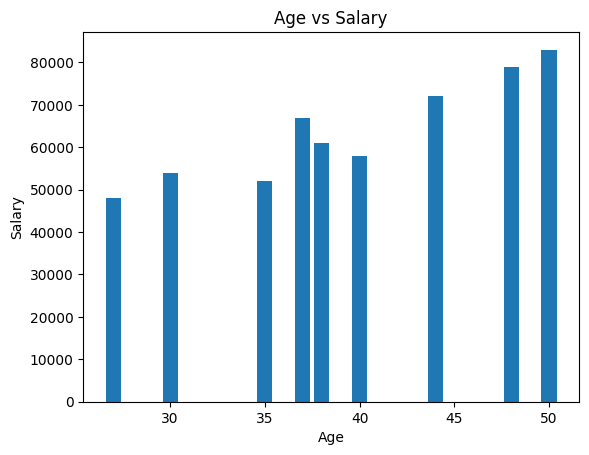

In [5]:
plt.bar(x,y)
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary')
plt.show()

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('Social_Network_Ads.csv')

In [8]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [9]:
df =df.iloc[:,2:]

In [12]:
df.sample(5)

,Age,EstimatedSalary,Purchased
79,26,17000,0
109,38,80000,0
328,36,118000,1
196,30,79000,0
226,36,126000,1


In [14]:
from sklearn.model_selection import train_test_split
X_train , X_test ,Y_train, Y_test = train_test_split(df.drop('Purchased' , axis=1) , df['Purchased'],test_size=0.3 , random_state=0)
X_train.shape , X_test.shape

((280, 2), (120, 2))

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [19]:
X_train_scaled = pd.DataFrame(X_train, columns=['Age', 'EstimatedSalary'])
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [21]:
X_train_scaled = pd.DataFrame(X_train, columns=['Age', 'EstimatedSalary'])
X_test_scaled = pd.DataFrame(X_test, columns=['Age', 'EstimatedSalary'])

In [22]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


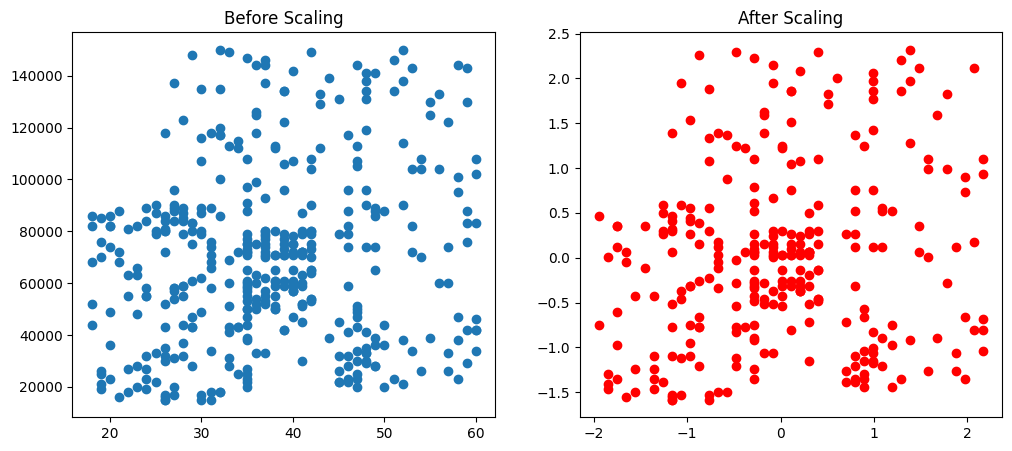

In [27]:
fig ,(ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.scatter(df['Age'], df['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'] , X_train_scaled["EstimatedSalary"], c='red')
ax2.set_title("After Scaling")
plt.show()

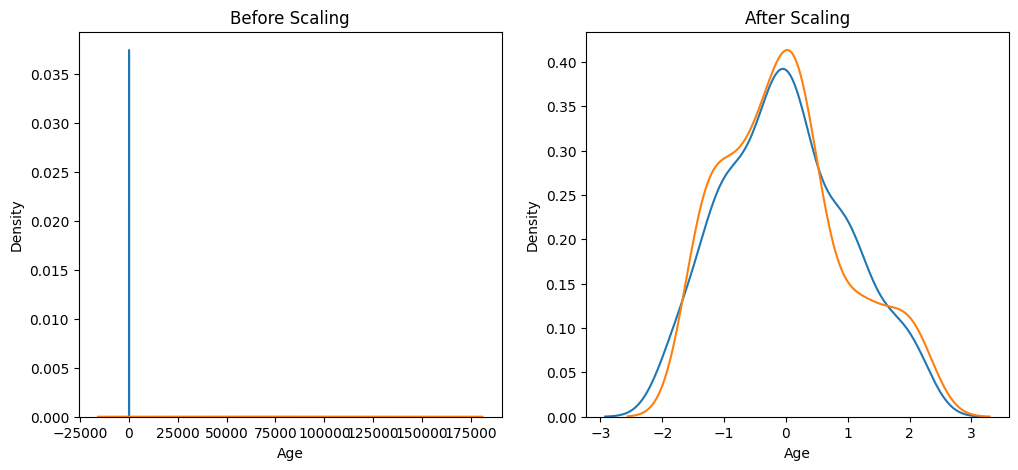

In [29]:
fig ,(ax1 ,ax2) = plt.subplots(ncols=2 , figsize=(12,5))
ax1.set_title("Before Scaling")
sns.kdeplot(df["Age"] , ax=ax1)
sns.kdeplot(df["EstimatedSalary"] , ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"] , ax=ax2)
sns.kdeplot(X_train_scaled["EstimatedSalary"] , ax=ax2)
plt.show()

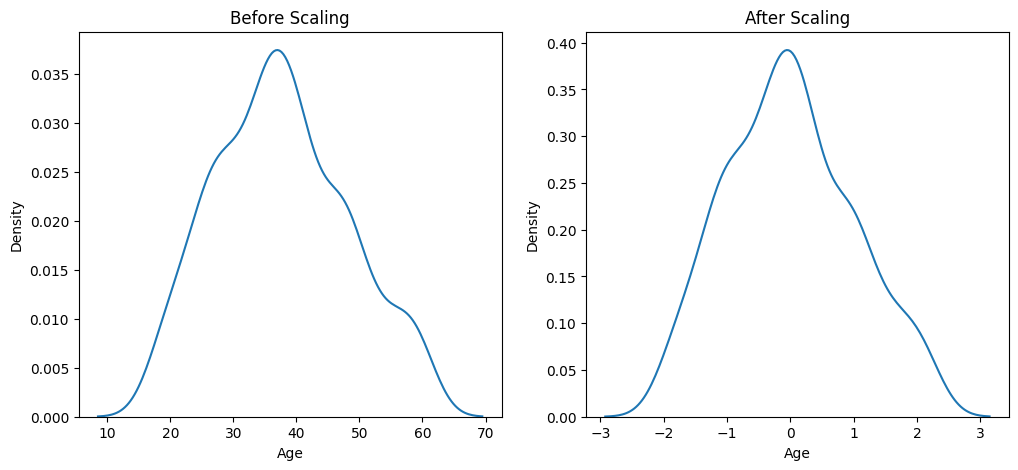

In [30]:
fig ,(ax1 ,ax2) = plt.subplots(ncols=2 , figsize=(12,5))
ax1.set_title("Before Scaling")
sns.kdeplot(df["Age"] , ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"] , ax=ax2)
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [32]:
lr.fit(X_train,Y_train)
lr_scaled.fit(X_train_scaled,Y_train)

LogisticRegression()

In [34]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [36]:
from sklearn.metrics import accuracy_score

In [39]:
print("Actual",accuracy_score(Y_test , y_pred))
print("Scaled",accuracy_score(Y_test , y_pred_scaled))

Actual 0.8666666666666667
Scaled 0.8666666666666667


In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [42]:
dt.fit(X_train,Y_train)
dt_scaled.fit(X_train_scaled,Y_train)

DecisionTreeClassifier()

In [43]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [44]:
print("Actual",accuracy_score(Y_test , y_pred))
print("Scaled",accuracy_score(Y_test , y_pred_scaled))

Actual 0.8666666666666667
Scaled 0.875


In [45]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [48]:
df = pd.concat([df, pd.DataFrame({'Age':[5,90,99],'EstimatedSalary':[1000,250000,350000],'Purchased' : [0,1,1]})], ignore_index=True)

In [49]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


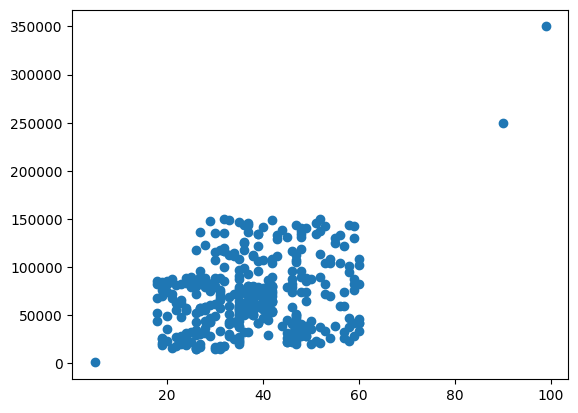

In [50]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [51]:
from sklearn.model_selection import train_test_split
X_train , X_test ,Y_train, Y_test = train_test_split(df.drop('Purchased' , axis=1) , df['Purchased'],test_size=0.3 , random_state=0)
X_train.shape , X_test.shape

((282, 2), (121, 2))

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
X_train_scaled = pd.DataFrame(X_train, columns=['Age', 'EstimatedSalary'])
X_train_scaled

,Age,EstimatedSalary
0,-0.652473,-0.995561
1,1.903047,2.092697
2,-0.104862,1.922701
3,-0.652473,0.562734
4,-0.013593,-0.287245
...,...,...
277,0.899092,-1.108891
278,-0.835010,-0.740567
279,-0.196130,-0.485573
280,-1.017547,-0.428908


In [ ]:
X_train_scaled = pd.DataFrame(X_train, columns=['Age', 'EstimatedSalary'])
X_test_scaled = pd.DataFrame(X_test, columns=['Age', 'EstimatedSalary'])

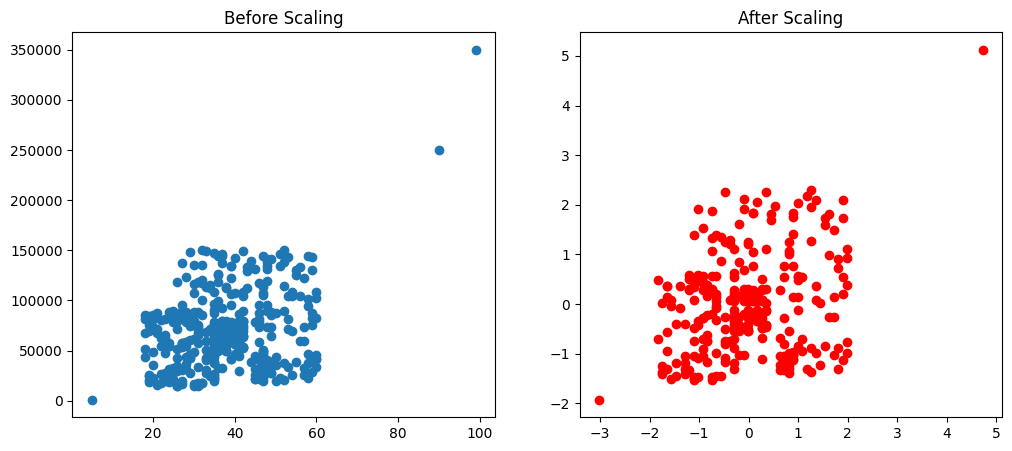

In [54]:
fig ,(ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.scatter(df['Age'], df['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'] , X_train_scaled["EstimatedSalary"], c='red')
ax2.set_title("After Scaling")
plt.show()